In [35]:
!pip install pandas numpy matplotlib seaborn nltk Sastrawi -q

1️⃣ Mount Google Drive

In [36]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2️⃣ Import Library

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from wordcloud import WordCloud

3️⃣ Load Dataset

In [38]:
# Jika menggunakan Google Colab, gunakan path ini:
file_path = "/content/drive/MyDrive/NLP Lanjut/Hoax Detection/scraping-data/news_data.csv"

# Jika menggunakan Jupyter Notebook di lokal, ganti path ke lokasi file di komputer
df = pd.read_csv(file_path)

# Tampilkan informasi dataset
print("Informasi Dataset:")
print(df.info())

# Tampilkan 5 baris pertama
print("\n5 Baris Pertama Dataset:")
print(df.head())


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          1216 non-null   object
 1   date           175 non-null    object
 2   author         99 non-null     object
 3   content        1307 non-null   object
 4   source         1416 non-null   object
 5   label          1416 non-null   object
 6   clean_content  1307 non-null   object
dtypes: object(7)
memory usage: 77.6+ KB
None

5 Baris Pertama Dataset:
                                    title                       date author  \
0                            Liga Inggris  2025-02-21T09:00:44+07:00    NaN   
1                           Internasional  2025-02-21T10:15:59+07:00    NaN   
2                              BRI Liga 1  2025-02-20T11:23:37+07:00    NaN   
3           Hasto Kristiyanto Ditahan KPK                        NaN    NaN   
4  Top 3: Zodiak yang

4️⃣ Cek Missing Values

In [39]:
# Cek jumlah missing values
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

# Isi data kosong pada 'content' dengan string kosong
df['content'] = df['content'].fillna('')



Jumlah Missing Values per Kolom:
title             200
date             1241
author           1317
content           109
source              0
label               0
clean_content     109
dtype: int64


5️⃣ Preprocessing Teks

In [40]:
# Fungsi membersihkan teks
def clean_text(text):
    text = text.lower()  # Ubah ke huruf kecil
    text = re.sub(r'\d+', '', text)  # Hapus angka
    text = re.sub(r'[^\w\s]', '', text)  # Hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()  # Hapus spasi berlebih
    return text

# Terapkan preprocessing pada teks
df['clean_text'] = df['content'].apply(clean_text)

# Tampilkan contoh hasil preprocessing
print("\nContoh Hasil Preprocessing:")
print(df[['content', 'clean_text']].head())



Contoh Hasil Preprocessing:
                                             content  \
0   liputan6 Kisah menarik mulai terungkap ketika...   
1   liputan6 Menteri Transportasi Israel Miri Reg...   
2   liputan6 Kompetisi kasta tertinggi di Indones...   
3                                           liputan6   
4   liputan6 Artikel tentang 3 zodiak paling seru...   

                                          clean_text  
0  liputan kisah menarik mulai terungkap ketika r...  
1  liputan menteri transportasi israel miri regev...  
2  liputan kompetisi kasta tertinggi di indonesia...  
3                                            liputan  
4  liputan artikel tentang zodiak paling seru dan...  


6️⃣ Menentukan Topik Berita

In [41]:
# Fungsi menentukan topik berdasarkan kata kunci
def assign_topic(text):
    text_lower = text.lower()

    politik_keywords = ['presiden', 'politik', 'partai', 'pemilu', 'pemerintah', 'menteri']
    penipuan_keywords = ['penipuan', 'scam', 'phishing', 'tipu', 'fraud', 'bohong']

    if any(keyword in text_lower for keyword in politik_keywords):
        return 'Politik'
    elif any(keyword in text_lower for keyword in penipuan_keywords):
        return 'Penipuan'
    else:
        return 'Umum'

# Tambahkan kolom 'topic' berdasarkan teks berita
df['topic'] = df['clean_text'].apply(assign_topic)

# Tampilkan distribusi topik
print("\nDistribusi Topik:")
print(df['topic'].value_counts())



Distribusi Topik:
topic
Umum        784
Politik     623
Penipuan      9
Name: count, dtype: int64


7️⃣ Membuat Label Akhir

In [42]:
# Gabungkan topik dengan label hoax/non-hoax jika kolom 'label' ada
if 'label' in df.columns:
    df['final_label'] = df['topic'] + ' (' + df['label'] + ')'

# Tampilkan distribusi final_label jika tersedia
if 'final_label' in df.columns:
    print("\nDistribusi Label Akhir:")
    print(df['final_label'].value_counts())



Distribusi Label Akhir:
final_label
Umum (non-hoax)        766
Politik (non-hoax)     621
Umum (hoax)             18
Penipuan (non-hoax)      9
Politik (hoax)           2
Name: count, dtype: int64


8️⃣ Exploratory Data Analysis (EDA)

<ipython-input-43-afb7af8f282e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='final_label', data=df, palette="coolwarm")


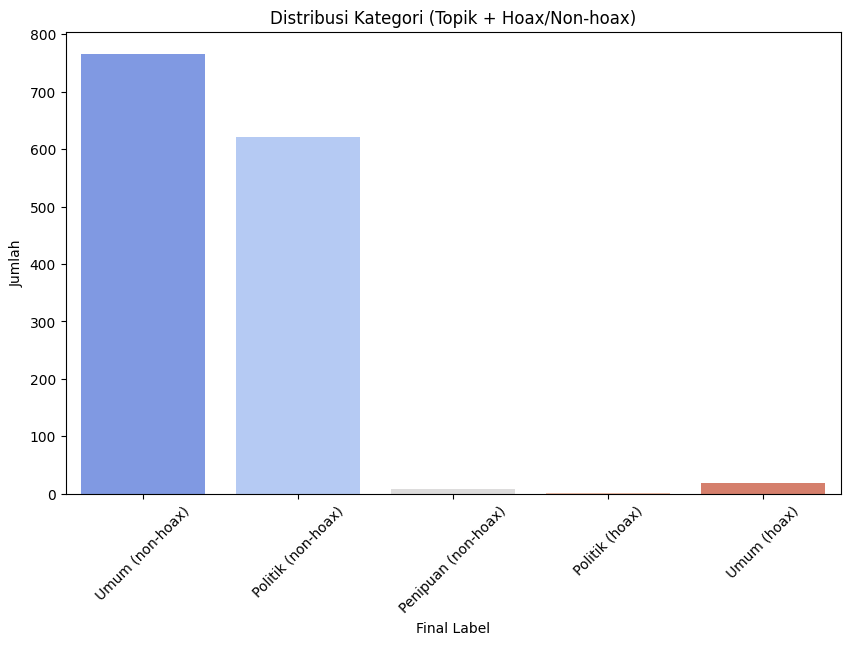

In [43]:
if 'final_label' in df.columns:
    plt.figure(figsize=(10,6))
    sns.countplot(x='final_label', data=df, palette="coolwarm")
    plt.title("Distribusi Kategori (Topik + Hoax/Non-hoax)")
    plt.xlabel("Final Label")
    plt.ylabel("Jumlah")
    plt.xticks(rotation=45)
    plt.show()


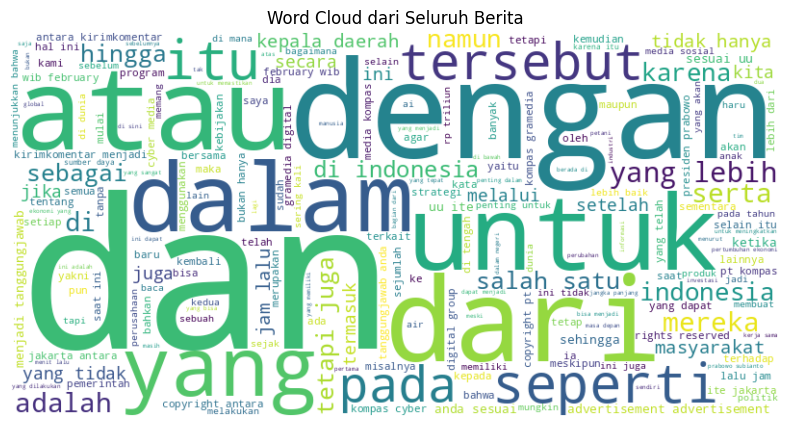

In [44]:
all_text = " ".join(df['clean_text'].tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud dari Seluruh Berita")
plt.show()


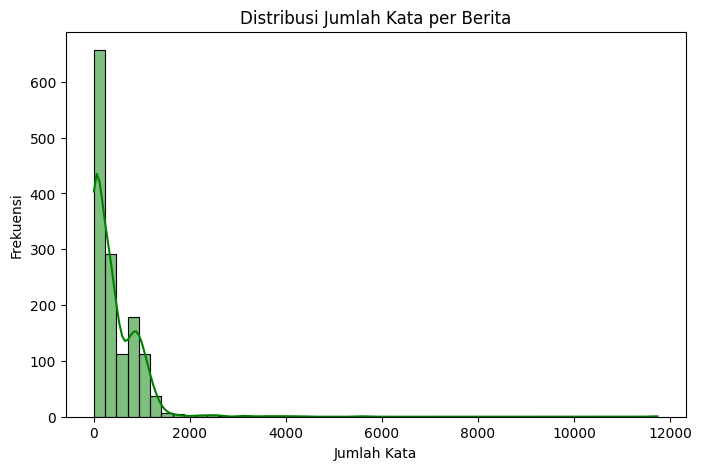

In [45]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=50, kde=True, color='green')
plt.title("Distribusi Jumlah Kata per Berita")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()


8️⃣ Simpan Data Baru

In [46]:
# Simpan dataset yang telah diproses
processed_file_path = "/content/drive/MyDrive/NLP Lanjut/Hoax Detection/eda-preprocessing-data/news_data_processed.csv"
df.to_csv(processed_file_path, index=False)

print(f"Dataset yang telah diproses berhasil disimpan di: {processed_file_path}")

Dataset yang telah diproses berhasil disimpan di: /content/drive/MyDrive/NLP Lanjut/Hoax Detection/eda-preprocessing-data/news_data_processed.csv
